<a href="https://colab.research.google.com/github/Vinuthna781/Dissertation_MOVE_VIX_Crash-Analysis/blob/main/Dissertation_Python_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Treasury Market Stress as a Leading Signal for Equity Momentum Crashes: Incremental Predictive Power of the MOVE Index Beyond Equity Volatility

**Author:** Sai Vinuthna Nagisetty (CID: 06040876)
**Programme:** MSc Investment & Wealth Management, Imperial College Business School
**Sample:** Monthly data, January 1990 – December 2024 (420 observations)

---

## The research question is:

> *Does lagged MOVE (Treasury implied volatility) significantly improve out-of-sample prediction of equity
> momentum (UMD) and low-volatility (BAB) factor drawdowns, relative to a VIX-only benchmark?*



## 1. Imports and Setup

`pandas`/`numpy` for data handling, `statsmodels` for the interpretable
in-sample logistic regression (proper coefficient tables, standard errors, p-values), and `sklearn` for the walk-forward out-of-sample logistic regression and evaluation metrics
(AUC, Brier score). `matplotlib` for diagnostic plots.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import os
import urllib.request

os.makedirs("data", exist_ok=True)

DATA_URL = "https://raw.githubusercontent.com/Vinuthna781/Dissertation_MOVE_VIX_Crash-Analysis/main/data/master_complete_case.xlsx"
DATA_PATH = "data/master_complete_case.xlsx"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42



## 2. Data Loading

Loading the cleaned master dataset (`master_complete_case.xlsx`)
This file has:
1. All six raw sources merged on month-end date
2. Units standardised to decimal (French and AQR percent-return files converted; MOVE/VIX left as index levels)
3. Realised volatility computed from daily SPX log returns
4. Zero missing values across the full **January 1990 – December 2024** window (420 monthly observations)


In [2]:

df = pd.read_excel("data/master_complete_case.xlsx", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Missing values:\n{df.isna().sum().sum()} total")
df.head()


Shape: (420, 11)
Date range: 1990-01-31 to 2024-12-31
Missing values:
0 total


,Date,MOVE,VIX,mkt_return_monthly,realised_vol,UMD,Mkt_RF,SMB,HML,RF,BAB
0,1990-01-31,105.5000,25.3600,-0.0713,0.0540,-0.0327,-0.0780,-0.0114,0.0083,0.0057,-0.0022
1,1990-02-28,105.7200,21.9900,0.0085,0.0317,-0.0055,0.0112,0.0097,0.0065,0.0057,-0.0135
2,1990-03-31,103.8900,19.7300,0.0240,0.0321,0.0180,0.0183,0.0147,-0.0290,0.0064,-0.0021
3,1990-04-30,104.6300,19.5200,-0.0273,0.0311,0.0239,-0.0336,-0.0047,-0.0257,0.0069,-0.0246
4,1990-05-31,94.7000,17.3700,0.0880,0.0366,0.0303,0.0843,-0.0256,-0.0389,0.0068,-0.0201


In [ ]:

df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,420,2007-07-16 06:24:00,1990-01-31 00:00:00,1998-10-23 06:00:00,2007-07-15 12:00:00,2016-04-07 12:00:00,2024-12-31 00:00:00,NaN
MOVE,420.0000,92.9519,39.2100,72.6078,91.1650,108.2250,214.0000,27.7705
VIX,420.0000,19.5389,9.5100,13.7575,17.6650,23.5050,59.8900,7.5035
mkt_return_monthly,420.0000,0.0067,-0.1856,-0.0179,0.0116,0.0342,0.1194,0.0431
realised_vol,420.0000,0.0444,0.0122,0.0279,0.0374,0.0521,0.2734,0.0274
UMD,420.0000,0.0046,-0.3430,-0.0137,0.0052,0.0293,0.1820,0.0467
Mkt_RF,420.0000,0.0073,-0.1720,-0.0195,0.0122,0.0343,0.1360,0.0442
SMB,420.0000,0.0006,-0.1741,-0.0194,0.0006,0.0176,0.2125,0.0313
HML,420.0000,0.0013,-0.1383,-0.0166,-0.0009,0.0167,0.1286,0.0324
RF,420.0000,0.0022,0.0000,0.0001,0.0019,0.0040,0.0069,0.0019



## 3. MOVE and VIX Over Time

Checking to see if both MOVE and VIX show pronounced spikes during the known stress periods
(the 2008 Global Financial Crisis, March 2020 COVID shock, and the 2022 rate-shock period).

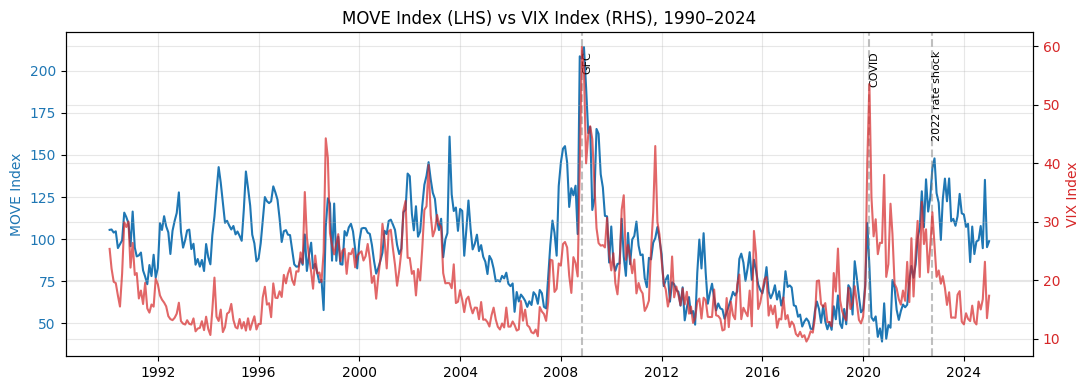

In [ ]:

fig, ax1 = plt.subplots()

ax1.plot(df["Date"], df["MOVE"], color="tab:blue", label="MOVE Index")
ax1.set_ylabel("MOVE Index", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["VIX"], color="tab:red", alpha=0.7, label="VIX Index")
ax2.set_ylabel("VIX Index", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

for date, label in [("2008-10-31", "GFC"), ("2020-03-31", "COVID"), ("2022-09-30", "2022 rate shock")]:
    ax1.axvline(pd.Timestamp(date), color="grey", linestyle="--", alpha=0.5)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1]*0.95, label, rotation=90, fontsize=8, va="top")

plt.title("MOVE Index (LHS) vs VIX Index (RHS), 1990\u20132024")
fig.tight_layout()
plt.show()



## 4. Crash Indicator Definition

**The crash threshold must be computed using only data
available at the time of each prediction.**

At every walk-forward step, the 10th-percentile threshold is recomputed using only the
training window's own historical returns. The
actual outcome for month *t* is then labelled a crash if the realised return at *t* falls below that
training-derived threshold.

Checking the full sample for reference on the crash frequency and the 10th percentile. The walk forward is implemented in the full model in the later sections.


In [ ]:

umd_full_threshold = df["UMD"].quantile(0.10)
bab_full_threshold = df["BAB"].quantile(0.10)

print(f"Full-sample 10th percentile (reference only, not used in OOS modelling):")
print(f"  UMD: {umd_full_threshold:.4f}")
print(f"  BAB: {bab_full_threshold:.4f}")
print()
print(f"Full-sample crash frequency (reference only):")
print(f"  UMD: {(df['UMD'] < umd_full_threshold).mean():.1%}")
print(f"  BAB: {(df['BAB'] < bab_full_threshold).mean():.1%}")


Full-sample 10th percentile (reference only, not used in OOS modelling):
  UMD: -0.0464
  BAB: -0.0300

Full-sample crash frequency (reference only):
  UMD: 10.0%
  BAB: 10.0%



## 5. Constructing Lags, Ratio, and Controls

**Predictors constructed for each lag (1, 2, 3 months):**

- `MOVE_lag{k}`, `VIX_lag{k}` — the index levels, lagged *k* months
- `ratio_lag{k}` = `MOVE_lag{k} / VIX_lag{k}` — same lag applied to both components, for consistency
- `mktret_lag{k}`, `rvol_lag{k}` — market return and realised volatility controls, **also lagged by the
  same *k***

The same lag (*k*) is applied uniformly to every predictor in a given specification making the
MOVE-vs-VIX comparison at each lag a fair one.


In [ ]:

LAGS = [1, 2, 3]

feat = df.copy()
for k in LAGS:
    feat[f"MOVE_lag{k}"]   = feat["MOVE"].shift(k)
    feat[f"VIX_lag{k}"]    = feat["VIX"].shift(k)
    feat[f"ratio_lag{k}"]  = feat[f"MOVE_lag{k}"] / feat[f"VIX_lag{k}"]
    feat[f"mktret_lag{k}"] = feat["mkt_return_monthly"].shift(k)
    feat[f"rvol_lag{k}"]   = feat["realised_vol"].shift(k)

feat = feat.dropna().reset_index(drop=True)
print(f"Shape after lagging and dropping initial NaN rows: {feat.shape}")
print(f"Usable date range: {feat['Date'].min().date()} to {feat['Date'].max().date()}")
feat.head()


Shape after lagging and dropping initial NaN rows: (417, 26)
Usable date range: 1990-04-30 to 2024-12-31


,Date,MOVE,VIX,mkt_return_monthly,realised_vol,UMD,Mkt_RF,SMB,HML,RF,...,MOVE_lag2,VIX_lag2,ratio_lag2,mktret_lag2,rvol_lag2,MOVE_lag3,VIX_lag3,ratio_lag3,mktret_lag3,rvol_lag3
0,1990-04-30,104.6300,19.5200,-0.0273,0.0311,0.0239,-0.0336,-0.0047,-0.0257,0.0069,...,105.7200,21.9900,4.8076,0.0085,0.0317,105.5000,25.3600,4.1601,-0.0713,0.0540
1,1990-05-31,94.7000,17.3700,0.0880,0.0366,0.0303,0.0843,-0.0256,-0.0389,0.0068,...,103.8900,19.7300,5.2656,0.0240,0.0321,105.7200,21.9900,4.8076,0.0085,0.0317
2,1990-06-30,96.9800,15.5000,-0.0089,0.0368,0.0240,-0.0109,0.0135,-0.0200,0.0063,...,104.6300,19.5200,5.3601,-0.0273,0.0311,103.8900,19.7300,5.2656,0.0240,0.0321
3,1990-07-31,99.2900,21.1100,-0.0052,0.0361,0.0610,-0.0190,-0.0308,-0.0006,0.0068,...,94.7000,17.3700,5.4519,0.0880,0.0366,104.6300,19.5200,5.3601,-0.0273,0.0311
4,1990-08-31,115.7300,29.9000,-0.0991,0.0767,0.0188,-0.1012,-0.0350,0.0156,0.0066,...,96.9800,15.5000,6.2568,-0.0089,0.0368,94.7000,17.3700,5.4519,0.0880,0.0366



## 6. Model Specifications

**Baseline (VIX-only):**
$$P(\text{Crash}_t = 1) = \Lambda(\beta_0 + \beta_1 \text{VIX}_{t-k} + \beta_2 \text{mktret}_{t-k} + \beta_3 \text{rvol}_{t-k})$$

**Full (VIX + MOVE):**
$$P(\text{Crash}_t = 1) = \Lambda(\beta_0 + \beta_1 \text{VIX}_{t-k} + \beta_2 \text{MOVE}_{t-k} + \beta_3 \text{mktret}_{t-k} + \beta_4 \text{rvol}_{t-k})$$

where $\Lambda(\cdot)$ is the logistic function.


In [ ]:

def get_feature_sets(lag):
    baseline   = [f"VIX_lag{lag}", f"mktret_lag{lag}", f"rvol_lag{lag}"]
    full       = [f"VIX_lag{lag}", f"MOVE_lag{lag}", f"mktret_lag{lag}", f"rvol_lag{lag}"]
    full_ratio = [f"VIX_lag{lag}", f"MOVE_lag{lag}", f"ratio_lag{lag}", f"mktret_lag{lag}", f"rvol_lag{lag}"]
    return baseline, full, full_ratio

# quick check
b, f, _ = get_feature_sets(1)
print("Baseline features (lag 1):", b)
print("Full features (lag 1):    ", f)


Baseline features (lag 1): ['VIX_lag1', 'mktret_lag1', 'rvol_lag1']
Full features (lag 1):     ['VIX_lag1', 'MOVE_lag1', 'mktret_lag1', 'rvol_lag1']



## 7. Diagnostic: Multicollinearity Check (VIF)

MOVE and VIX are both stress gauges and are likely to be correlated.
Full model's coefficients become unstable and hard to interpret if the correlation high.
Variance Inflation Factor (VIF) is computed on the lag-1 feature set as a diagnostic, for **both** the
"with ratio" and "no ratio" specifications, to see directly how much of the multicollinearity problem is
caused by including the redundant ratio term.


In [ ]:

lag = 1
_, full_no_ratio_features, full_ratio_features = get_feature_sets(lag)

print(f"Correlation, MOVE_lag{lag} vs VIX_lag{lag}: {feat[f'MOVE_lag{lag}'].corr(feat[f'VIX_lag{lag}']):.3f}")
print()

for label, feats_for_vif in [("Full + ratio (excluded, diagnostic only)", full_ratio_features), ("Full", full_no_ratio_features)]:
    X_vif = sm.add_constant(feat[feats_for_vif])
    vif_data = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })
    vif_data = vif_data[vif_data["feature"] != "const"].reset_index(drop=True)
    print(f"--- {label} ---")
    print(vif_data.to_string(index=False))
    print()


Correlation, MOVE_lag1 vs VIX_lag1: 0.474

--- Full + ratio (excluded, diagnostic only) ---
    feature     VIF
   VIX_lag1 12.3071
  MOVE_lag1  7.0393
 ratio_lag1  7.9828
mktret_lag1  1.2141
  rvol_lag1  3.7037

--- Full ---
    feature    VIF
   VIX_lag1 3.8777
  MOVE_lag1 1.3091
mktret_lag1 1.2106
  rvol_lag1 3.6604




## 8. Walk-Forward Out-of-Sample Validation Framework

**Expanding window, 180-month (15-year) initial training period.**

This follows standard practice in the out-of-sample financial forecasting literature: Rapach, Strauss &
Zhou (2010, *Review of Financial Studies*), the most widely cited reference for monthly out-of-sample
equity-premium prediction, use an expanding window, and expanding windows are the general convention in
this literature. The reasoning for choosing expanding over a fixed rolling window here is specific to this
project: because crash months are rare by construction (~10% of the sample), a rolling window with a fixed,
short lookback risks landing on windows containing very few or even zero crash events, which can break
logistic regression estimation entirely. An expanding window never shrinks the effective sample, so this
risk falls over time rather than persisting throughout the OOS period.


1. Training data = all months strictly before *t*
2. The crash threshold is computed **from the training data's own returns only**
3. Training labels are assigned using that threshold
4. A logistic regression is fit on the training window
5. The model predicts a crash probability for month *t*
6. Month *t*'s actual outcome is labelled using the same training-derived threshold
7. Move forward one month and then repeated

The 180-month initial window (1990–2004 in calendar terms, adjusted for the lag offset) leaves roughly
230–240 out-of-sample months for evaluation, spanning the 2008 GFC, the 2020 COVID shock and the 2022 rate
shock, this gives the OOS period genuine crash episodes to test against, not just calm markets.


The function below
fixes this by standardizing every feature (zero mean, unit variance) **using only the training window's
own mean/standard deviation, then applying that same transformation to the test row**


In [ ]:

from sklearn.preprocessing import StandardScaler

def walk_forward_logit(data, outcome_col, feature_cols, initial_window=180, pct=0.10, verbose=False, C=1.0):
    # Expanding-window walk-forward logistic regression, with per-step feature standardization
    # (scaler fit on the training window only, then applied to the single test row).
    #
    # data          : DataFrame sorted by Date, already lagged/feature-engineered, no NaNs
    # outcome_col   : column name of the RAW monthly return (e.g. 'UMD' or 'BAB') used to derive crash labels
    # feature_cols  : list of predictor column names
    # initial_window: number of months in the first training window before OOS predictions begin
    # pct           : percentile threshold for crash definition (0.10 = bottom 10th percentile)
    # C             : sklearn LogisticRegression inverse regularisation strength (default 1.0, matching
    #                 every existing call in this notebook passing a different C is additive and does
    #                 not change any previously reported result)
    #
    # Returns a DataFrame of out-of-sample predictions: Date, actual, predicted_prob, threshold_used
    n = len(data)
    results = []
    skipped = 0

    for t in range(initial_window, n):
        train = data.iloc[:t]
        test_row = data.iloc[[t]]

        threshold = train[outcome_col].quantile(pct)
        y_train = (train[outcome_col] < threshold).astype(int)
        y_test_actual = int(test_row[outcome_col].values[0] < threshold)

        # Skip steps where the training window has no variation in the outcome (can't fit logistic regression)
        if y_train.nunique() < 2:
            skipped += 1
            continue

        X_train_raw = train[feature_cols].values
        X_test_raw = test_row[feature_cols].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=C)
        model.fit(X_train, y_train)
        pred_prob = model.predict_proba(X_test)[0, 1]

        results.append({
            "Date": test_row["Date"].values[0],
            "actual": y_test_actual,
            "predicted_prob": pred_prob,
            "threshold_used": threshold,
        })

    if verbose:
        print(f"  Completed {len(results)} OOS predictions, skipped {skipped} steps (no label variation in training window)")

    return pd.DataFrame(results)



## 9. Main Analysis

Running the walk-forward validation: **2 outcome variables (UMD, BAB) × 2 model
specifications (Baseline, Full no-ratio) × 3 lags (1, 2, 3) = 12 walk-forward runs**, each
producing an out-of-sample prediction series that is then scored with AUC and Brier score. Features are
now standardized within each walk-forward step.

In [ ]:

OUTCOMES = ["UMD", "BAB"]

main_results = []
oos_predictions = {}  # keyed by (outcome, spec_name, lag) -> DataFrame

for outcome in OUTCOMES:
    for lag in LAGS:
        baseline_feats, full_feats, _ = get_feature_sets(lag)
        specs = [
            ("Baseline (VIX-only)", baseline_feats),
            ("Full (VIX+MOVE)", full_feats),
        ]
        for spec_name, feats in specs:
            print(f"Running: outcome={outcome}, lag={lag}, spec={spec_name} ...")
            oos = walk_forward_logit(feat, outcome_col=outcome, feature_cols=feats,
                                      initial_window=180, pct=0.10, verbose=True)
            oos_predictions[(outcome, spec_name, lag)] = oos

            auc = roc_auc_score(oos["actual"], oos["predicted_prob"])
            brier = brier_score_loss(oos["actual"], oos["predicted_prob"])
            n_crashes = oos["actual"].sum()

            main_results.append({
                "Outcome": outcome, "Lag": lag, "Model": spec_name,
                "N_OOS": len(oos), "N_crash_events": int(n_crashes),
                "AUC": auc, "Brier": brier
            })

main_results_df = pd.DataFrame(main_results)
main_results_df


Running: outcome=UMD, lag=1, spec=Baseline (VIX-only) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=1, spec=Full (VIX+MOVE) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=2, spec=Baseline (VIX-only) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=2, spec=Full (VIX+MOVE) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=3, spec=Baseline (VIX-only) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=3, spec=Full (VIX+MOVE) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=BAB, lag=1, spec=Baseline (VIX-only) ...
  Completed 237 OOS predictions, skipped 0 steps (no label variation in 

,Outcome,Lag,Model,N_OOS,N_crash_events,AUC,Brier
0,UMD,1,Baseline (VIX-only),237,21,0.7736,0.0764
1,UMD,1,Full (VIX+MOVE),237,21,0.7546,0.0783
2,UMD,2,Baseline (VIX-only),237,21,0.7542,0.0797
3,UMD,2,Full (VIX+MOVE),237,21,0.7299,0.0809
4,UMD,3,Baseline (VIX-only),237,21,0.7910,0.0809
5,UMD,3,Full (VIX+MOVE),237,21,0.7304,0.0834
6,BAB,1,Baseline (VIX-only),237,14,0.8270,0.0558
7,BAB,1,Full (VIX+MOVE),237,14,0.8280,0.0556
8,BAB,2,Baseline (VIX-only),237,14,0.7124,0.0681
9,BAB,2,Full (VIX+MOVE),237,14,0.6823,0.0694



## 10. Results Table and Interpretation Guide

- **AUC** (Area Under the ROC Curve) measures discrimination, the probability that the model ranks a
  randomly chosen crash month higher than a randomly chosen non-crash month.
- **Brier score** measures the mean squared error between predicted probabilities and actual outcomes.

For a given outcome variable and lag, the **Full**
model showing a **higher AUC and/or lower Brier score** than the **Baseline** model indicates MOVE
contributes incremental predictive power beyond VIX alone.


In [ ]:

pivot_auc = main_results_df.pivot_table(index=["Outcome", "Lag"], columns="Model", values="AUC")
pivot_auc["AUC_improvement"] = pivot_auc["Full (VIX+MOVE)"] - pivot_auc["Baseline (VIX-only)"]

pivot_brier = main_results_df.pivot_table(index=["Outcome", "Lag"], columns="Model", values="Brier")
pivot_brier["Brier_improvement"] = pivot_brier["Baseline (VIX-only)"] - pivot_brier["Full (VIX+MOVE)"]

print("=== AUC comparison (higher = better; positive improvement favours MOVE) ===")
display(pivot_auc)
print()
print("=== Brier score comparison (lower = better; positive improvement favours MOVE) ===")
display(pivot_brier)


=== AUC comparison (higher = better; positive improvement favours MOVE) ===


Model        Baseline (VIX-only)  Full (VIX+MOVE)  AUC_improvement
Outcome Lag                                                       
BAB     1                 0.8270           0.8280           0.0010
        2                 0.7124           0.6823          -0.0301
        3                 0.7707           0.7306          -0.0400
UMD     1                 0.7736           0.7546          -0.0190
        2                 0.7542           0.7299          -0.0243
        3                 0.7910           0.7304          -0.0606


=== Brier score comparison (lower = better; positive improvement favours MOVE) ===


Model        Baseline (VIX-only)  Full (VIX+MOVE)  Brier_improvement
Outcome Lag                                                         
BAB     1                 0.0558           0.0556             0.0002
        2                 0.0681           0.0694            -0.0013
        3                 0.0620           0.0620            -0.0000
UMD     1                 0.0764           0.0783            -0.0019
        2                 0.0797           0.0809            -0.0013
        3                 0.0809           0.0834            -0.0026

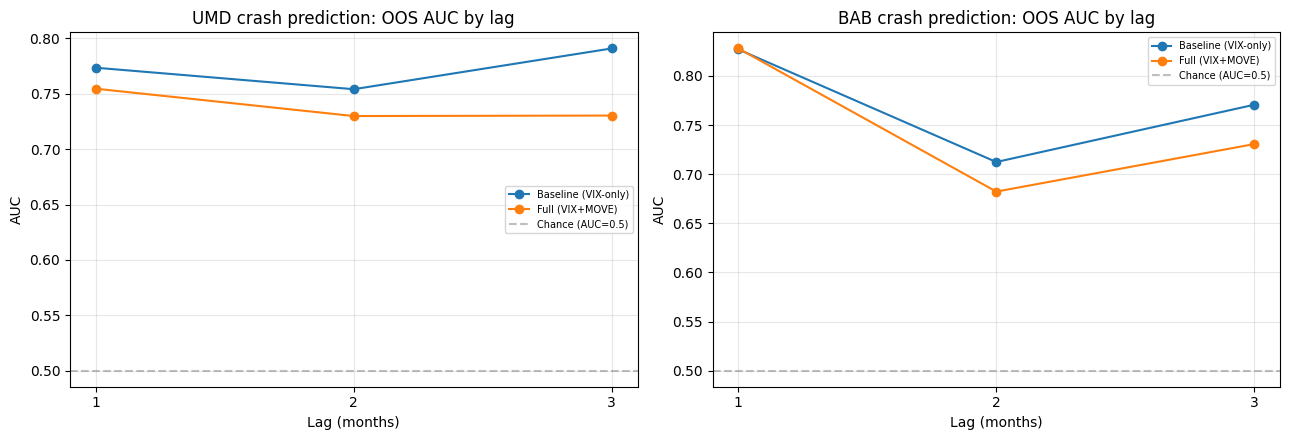

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, outcome in zip(axes, OUTCOMES):
    sub = main_results_df[main_results_df["Outcome"] == outcome]
    for spec_name, group in sub.groupby("Model"):
        ax.plot(group["Lag"], group["AUC"], marker="o", label=spec_name)
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance (AUC=0.5)")
    ax.set_title(f"{outcome} crash prediction: OOS AUC by lag")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("AUC")
    ax.set_xticks(LAGS)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()



## 11. Robustness Check 1: Alternate Crash Threshold (5th Percentile)

Repeating the entire walk-forward grid with a **stricter** crash definition; bottom 5th percentile instead
of 10th



In [ ]:

robustness_results = []

for outcome in OUTCOMES:
    for lag in LAGS:
        baseline_feats, full_feats, _ = get_feature_sets(lag)
        specs = [
            ("Baseline (VIX-only)", baseline_feats),
            ("Full (VIX+MOVE)", full_feats),
        ]
        for spec_name, feats in specs:
            oos = walk_forward_logit(feat, outcome_col=outcome, feature_cols=feats,
                                      initial_window=180, pct=0.05, verbose=False)
            if oos["actual"].nunique() < 2:
                auc, brier = np.nan, np.nan
            else:
                auc = roc_auc_score(oos["actual"], oos["predicted_prob"])
                brier = brier_score_loss(oos["actual"], oos["predicted_prob"])

            robustness_results.append({
                "Outcome": outcome, "Lag": lag, "Model": spec_name,
                "N_OOS": len(oos), "N_crash_events": int(oos["actual"].sum()),
                "AUC": auc, "Brier": brier
            })

robustness_df = pd.DataFrame(robustness_results)
print("=== Robustness: 5th percentile crash threshold ===")
robustness_df.pivot_table(index=["Outcome", "Lag"], columns="Model", values=["AUC", "Brier"])


=== Robustness: 5th percentile crash threshold ===


AUC                               Brier  \
Model       Baseline (VIX-only) Full (VIX+MOVE) Baseline (VIX-only)   
Outcome Lag                                                           
BAB     1                0.8130          0.8472              0.0329   
        2                0.7658          0.7528              0.0334   
        3                0.7391          0.5975              0.0340   
UMD     1                0.8264          0.7626              0.0469   
        2                0.7907          0.7586              0.0454   
        3                0.8489          0.7996              0.0438   

                             
Model       Full (VIX+MOVE)  
Outcome Lag                  
BAB     1            0.0313  
        2            0.0346  
        3            0.0337  
UMD     1            0.0484  
        2            0.0459  
        3            0.0438


## 12. Robustness Check 2: Lag Comparison Summary

Summarising how the Full model's incremental contribution changes across
lags, for both crash thresholds.

In [ ]:

main_results_df["Threshold"] = "10th percentile"
robustness_df["Threshold"] = "5th percentile"
combined = pd.concat([main_results_df, robustness_df], ignore_index=True)

comparison = combined.pivot_table(index=["Outcome", "Threshold", "Lag"], columns="Model", values="AUC")
comparison["MOVE_contribution_AUC"] = comparison["Full (VIX+MOVE)"] - comparison["Baseline (VIX-only)"]
comparison.sort_index()


Model                        Baseline (VIX-only)  Full (VIX+MOVE)  \
Outcome Threshold       Lag                                         
BAB     10th percentile 1                 0.8270           0.8280   
                        2                 0.7124           0.6823   
                        3                 0.7707           0.7306   
        5th percentile  1                 0.8130           0.8472   
                        2                 0.7658           0.7528   
                        3                 0.7391           0.5975   
UMD     10th percentile 1                 0.7736           0.7546   
                        2                 0.7542           0.7299   
                        3                 0.7910           0.7304   
        5th percentile  1                 0.8264           0.7626   
                        2                 0.7907           0.7586   
                        3                 0.8489           0.7996   

Model                        MOVE_contribution_AUC  
Outcome Threshold       Lag                         
BAB     10th percentile 1                   0.0010  
                        2                  -0.0301  
                        3                  -0.0400  
        5th percentile  1                   0.0342  
                        2                  -0.0130  
                        3                  -0.1416  
UMD     10th percentile 1                  -0.0190  
                        2                  -0.0243  
                        3                  -0.0606  
        5th percentile  1                  -0.0639  
                        2                  -0.0322  
                        3                  -0.0493


## 13. In-Sample Coefficient Table




In [ ]:

lag = 1
baseline_feats, full_no_ratio_feats, full_ratio_feats = get_feature_sets(lag)
full_feats = full_no_ratio_feats

for outcome in OUTCOMES:
    threshold = feat[outcome].quantile(0.10)
    y = (feat[outcome] < threshold).astype(int)

    print("=" * 70)
    print(f"OUTCOME: {outcome}  |  Lag: {lag}  |  Full-sample crash threshold: {threshold:.4f}  |  N crashes: {y.sum()} / {len(y)}")
    print("=" * 70)

    X_full = sm.add_constant(feat[full_feats])
    model_full = sm.Logit(y, X_full).fit(disp=0)
    print("\n--- Full model (VIX + MOVE) ---")
    print(model_full.summary())
    print()


OUTCOME: UMD  |  Lag: 1  |  Full-sample crash threshold: -0.0467  |  N crashes: 42 / 417

--- Full model (VIX + MOVE) ---
                           Logit Regression Results                           
Dep. Variable:                    UMD   No. Observations:                  417
Model:                          Logit   Df Residuals:                      412
Method:                           MLE   Df Model:                            4
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.1719
Time:                        10:57:22   Log-Likelihood:                -112.80
converged:                       True   LL-Null:                       -136.22
Covariance Type:            nonrobust   LLR p-value:                 1.647e-09
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.7514      0.783     -7.349      0.000      -7.285      -4.218
VIX_la


## 14. Diagnostic Tests: Autocorrelation, Heteroskedasticity, Specification (RESET)

These diagnostics are run on the **lag-1, full-sample logistic regressions**

1. **Autocorrelation** — tested directly on the logit's Pearson residuals via the Ljung-Box test, since
   residual autocorrelation is a genuine concern with monthly time-series data regardless of model type.
2. **Heteroskedasticity** — tested on the **Linear Probability Model (LPM)** equivalent where Breusch-Pagan/White are the textbook-correct tools. The LPM result is used to justify
   (or not) reporting heteroskedasticity-robust standard errors for the logit's coefficients.
3. **Functional-form/specification (RESET-style)** — strict exogeneity cannot be formally established
   without a valid instrument. RESET-style specification test is run: powers of the fitted
   linear index are added to the model and tested for joint significance via a likelihood-ratio test.


In [ ]:

from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white
from statsmodels.graphics.tsaplots import plot_acf

diagnostic_models = {}  # store fitted full-sample logit models for reuse

for outcome in OUTCOMES:
    threshold = feat[outcome].quantile(0.10)
    y = (feat[outcome] < threshold).astype(int)
    X_full = sm.add_constant(feat[full_feats])
    diagnostic_models[outcome] = {"y": y, "X": X_full, "model": sm.Logit(y, X_full).fit(disp=0)}

print("Full-sample lag-1 logit models re-fit for diagnostics (UMD, BAB) — ready.")


Full-sample lag-1 logit models re-fit for diagnostics (UMD, BAB) — ready.



### 14.1 Autocorrelation: Ljung-Box Test on Pearson Residuals

$H_0$: residuals are not autocorrelated (white noise). A low p-value (< 0.05) rejects $H_0$, indicating the
model is leaving predictable time-series structure in its errors.


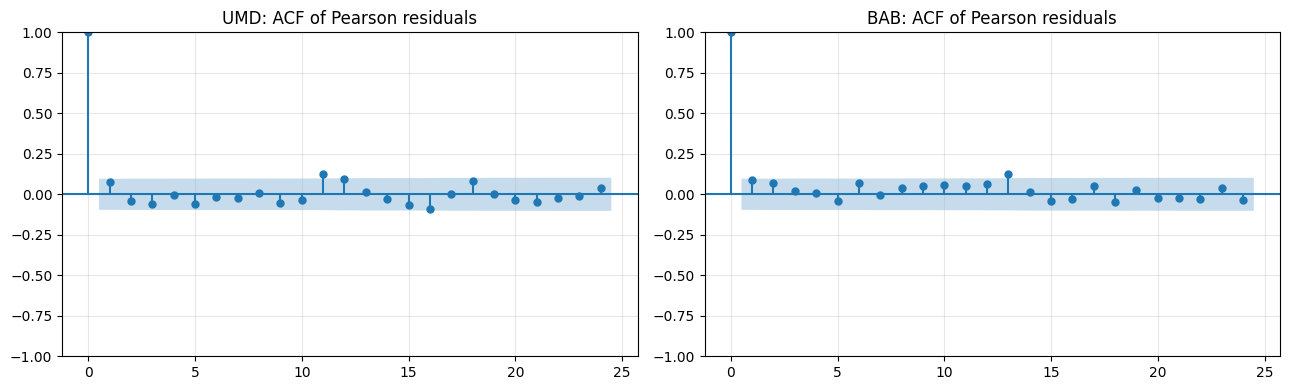

Ljung-Box test (H0: no autocorrelation up to the given lag)

--- UMD ---
    lb_stat  lb_pvalue
6    6.2350     0.3974
12  18.2680     0.1078

--- BAB ---
    lb_stat  lb_pvalue
6    8.5342     0.2015
12  14.4881     0.2706



In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, outcome in zip(axes, OUTCOMES):
    resid = diagnostic_models[outcome]["model"].resid_pearson
    plot_acf(resid, lags=24, ax=ax, title=f"{outcome}: ACF of Pearson residuals")

plt.tight_layout()
plt.show()

print("Ljung-Box test (H0: no autocorrelation up to the given lag)\n")
for outcome in OUTCOMES:
    resid = diagnostic_models[outcome]["model"].resid_pearson
    lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
    print(f"--- {outcome} ---")
    print(lb)
    print()



### 14.2 Heteroskedasticity: Breusch-Pagan and White Tests (via Linear Probability Model)

Running the LPM equivalent of the full model purely to obtain a
valid Breusch-Pagan / White test. $H_0$: homoskedastic errors. A low p-value (< 0.05) rejects $H_0$,
indicating heteroskedasticity,in which case the standard response is to report heteroskedasticity-robust (HC3)
standard errors, which is done for the logit model immediately after as a precaution regardless of the
test outcome.


In [ ]:

print("Breusch-Pagan and White tests (H0: homoskedasticity), via LPM (OLS) equivalent\n")

for outcome in OUTCOMES:
    y = diagnostic_models[outcome]["y"]
    X = diagnostic_models[outcome]["X"]
    lpm = sm.OLS(y, X).fit()

    bp_stat, bp_pval, _, _ = het_breuschpagan(lpm.resid, lpm.model.exog)
    white_stat, white_pval, _, _ = het_white(lpm.resid, lpm.model.exog)

    print(f"--- {outcome} (LPM diagnostic) ---")
    print(f"  Breusch-Pagan: LM stat = {bp_stat:.3f}, p-value = {bp_pval:.4f}")
    print(f"  White:         stat    = {white_stat:.3f}, p-value = {white_pval:.4f}")
    print()


Breusch-Pagan and White tests (H0: homoskedasticity), via LPM (OLS) equivalent

--- UMD (LPM diagnostic) ---
  Breusch-Pagan: LM stat = 44.101, p-value = 0.0000
  White:         stat    = 55.724, p-value = 0.0000

--- BAB (LPM diagnostic) ---
  Breusch-Pagan: LM stat = 50.253, p-value = 0.0000
  White:         stat    = 57.596, p-value = 0.0000



In [ ]:

print("Logit coefficients re-estimated with HC3 heteroskedasticity-robust standard errors\n")

for outcome in OUTCOMES:
    y = diagnostic_models[outcome]["y"]
    X = diagnostic_models[outcome]["X"]
    robust_model = sm.Logit(y, X).fit(disp=0, cov_type="HC3")
    print(f"--- {outcome}: Full model, lag 1, HC3 robust SEs ---")
    print(robust_model.summary().tables[1])
    print()


Logit coefficients re-estimated with HC3 heteroskedasticity-robust standard errors

--- UMD: Full model, lag 1, HC3 robust SEs ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.7514      0.775     -7.421      0.000      -7.270      -4.232
VIX_lag1        0.1459      0.039      3.714      0.000       0.069       0.223
MOVE_lag1       0.0047      0.006      0.731      0.465      -0.008       0.017
mktret_lag1     8.0975      3.915      2.069      0.039       0.425      15.770
rvol_lag1      -3.6672      9.554     -0.384      0.701     -22.392      15.058

--- BAB: Full model, lag 1, HC3 robust SEs ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.6051      0.869     -7.602      0.000      -8.308      -4.902
VIX_lag1        0.179


### 14.3 RESET-Style Functional-Form / Specification Test

$H_0$: the model is correctly specified (no evidence of omitted variables or functional-form
misspecification). Powers of the fitted linear index ($\hat{\eta}^2$, $\hat{\eta}^3$) are added to the
model; a likelihood-ratio test then checks whether they are jointly significant. Rejecting $H_0$ (p < 0.05)
signals evidence of functional-form misspecification or omitted nonlinear structure.


In [ ]:

print("RESET-style specification test (H0: no omitted nonlinearity / correct functional form)\n")

for outcome in OUTCOMES:
    y = diagnostic_models[outcome]["y"]
    X = diagnostic_models[outcome]["X"]
    base_model = diagnostic_models[outcome]["model"]

    fitted_index = base_model.predict(X, linear=True) if False else X.values @ base_model.params.values
    X_reset = X.copy()
    X_reset["fitted_sq"] = fitted_index ** 2
    X_reset["fitted_cb"] = fitted_index ** 3

    reset_model = sm.Logit(y, X_reset).fit(disp=0)

    lr_stat = 2 * (reset_model.llf - base_model.llf)
    df_diff = reset_model.df_model - base_model.df_model
    from scipy import stats as scipy_stats
    lr_pval = scipy_stats.chi2.sf(lr_stat, df_diff)

    print(f"--- {outcome} ---")
    print(f"  LR statistic = {lr_stat:.3f}, df = {df_diff}, p-value = {lr_pval:.4f}")
    verdict = "misspecification detected (reject H0)" if lr_pval < 0.05 else "no evidence of misspecification (fail to reject H0)"
    print(f"  Verdict: {verdict}")
    print()

print("\nResidual-predictor correlation check (descriptive only, expected \u2248 0 under correctly specified MLE)\n")
for outcome in OUTCOMES:
    resid = diagnostic_models[outcome]["model"].resid_pearson
    X = diagnostic_models[outcome]["X"].drop(columns=["const"])
    corrs = X.apply(lambda col: np.corrcoef(col, resid)[0, 1])
    print(f"--- {outcome} ---")
    print(corrs)
    print()


RESET-style specification test (H0: no omitted nonlinearity / correct functional form)

--- UMD ---
  LR statistic = 1.220, df = 2.0, p-value = 0.5434
  Verdict: no evidence of misspecification (fail to reject H0)

--- BAB ---
  LR statistic = 1.788, df = 2.0, p-value = 0.4091
  Verdict: no evidence of misspecification (fail to reject H0)


Residual-predictor correlation check (descriptive only, expected ≈ 0 under correctly specified MLE)

--- UMD ---
VIX_lag1       0.0188
MOVE_lag1      0.0235
mktret_lag1   -0.0220
rvol_lag1      0.0316
dtype: float64

--- BAB ---
VIX_lag1       0.0139
MOVE_lag1      0.0149
mktret_lag1   -0.0126
rvol_lag1      0.0159
dtype: float64




## 15. Summary of Numerical Results

Summary of the actual results produced, the best-performing
lag/model combination for each outcome variable, and whether the **Full, no ratio** model outperformed the Baseline (VIX-only) model
out-of-sample.

In [ ]:

print("SUMMARY: Out-of-sample MOVE contribution (10th percentile threshold, primary specification: Full, no ratio)\n")

PRIMARY_FULL = "Full (VIX+MOVE)"

for outcome in OUTCOMES:
    sub = main_results_df[main_results_df["Outcome"] == outcome]

    print(f"--- {outcome} ---")
    for lag in LAGS:
        base = sub[(sub["Lag"] == lag) & (sub["Model"] == "Baseline (VIX-only)")]
        full = sub[(sub["Lag"] == lag) & (sub["Model"] == PRIMARY_FULL)]
        if len(base) and len(full):
            base_auc, full_auc = base["AUC"].values[0], full["AUC"].values[0]
            base_brier, full_brier = base["Brier"].values[0], full["Brier"].values[0]
            direction = "MOVE ADDS VALUE" if full_auc > base_auc else "no AUC improvement"
            print(f"  Lag {lag}: Baseline AUC={base_auc:.3f}, Full AUC={full_auc:.3f} "
                  f"(\u0394={full_auc - base_auc:+.3f}) | Baseline Brier={base_brier:.4f}, Full Brier={full_brier:.4f} "
                  f"(\u0394={base_brier - full_brier:+.4f})  -->  {direction}")
    print()


SUMMARY: Out-of-sample MOVE contribution (10th percentile threshold, primary specification: Full, no ratio)

--- UMD ---
  Lag 1: Baseline AUC=0.774, Full AUC=0.755 (Δ=-0.019) | Baseline Brier=0.0764, Full Brier=0.0783 (Δ=-0.0019)  -->  no AUC improvement
  Lag 2: Baseline AUC=0.754, Full AUC=0.730 (Δ=-0.024) | Baseline Brier=0.0797, Full Brier=0.0809 (Δ=-0.0013)  -->  no AUC improvement
  Lag 3: Baseline AUC=0.791, Full AUC=0.730 (Δ=-0.061) | Baseline Brier=0.0809, Full Brier=0.0834 (Δ=-0.0026)  -->  no AUC improvement

--- BAB ---
  Lag 1: Baseline AUC=0.827, Full AUC=0.828 (Δ=+0.001) | Baseline Brier=0.0558, Full Brier=0.0556 (Δ=+0.0002)  -->  MOVE ADDS VALUE
  Lag 2: Baseline AUC=0.712, Full AUC=0.682 (Δ=-0.030) | Baseline Brier=0.0681, Full Brier=0.0694 (Δ=-0.0013)  -->  no AUC improvement
  Lag 3: Baseline AUC=0.771, Full AUC=0.731 (Δ=-0.040) | Baseline Brier=0.0620, Full Brier=0.0620 (Δ=-0.0000)  -->  no AUC improvement




## 16. Supplementary Check: Extended Transmission Horizons (Lags 6 and 12 Months)

**This section is supplementary, not part of the primary specification.**

If MOVE's predictive power is genuinely absent at short horizons
but present at longer ones, that would point to a slower transmission channel. Six and twelve
months were chosen (rather than a dense sweep of every possible lag) because they are the shortest and most
commonly used horizons in the related return-predictability literature (e.g. the bond-equity fear-divergence
literature cited earlier tests k = 1, 3, 6, 9, 12, 24 months).

Any positive result at lag 6 or 12 will be reported as
exploratory and flagged for future research with a larger or extended sample, not treated with the same
confidence as the primary specification.



In [ ]:

SUPPLEMENTARY_LAGS = [6, 12]

feat_supp = df.copy()
for k in SUPPLEMENTARY_LAGS:
    feat_supp[f"MOVE_lag{k}"]   = feat_supp["MOVE"].shift(k)
    feat_supp[f"VIX_lag{k}"]    = feat_supp["VIX"].shift(k)
    feat_supp[f"ratio_lag{k}"]  = feat_supp[f"MOVE_lag{k}"] / feat_supp[f"VIX_lag{k}"]
    feat_supp[f"mktret_lag{k}"] = feat_supp["mkt_return_monthly"].shift(k)
    feat_supp[f"rvol_lag{k}"]   = feat_supp["realised_vol"].shift(k)

feat_supp = feat_supp.dropna().reset_index(drop=True)
print(f"Shape after lagging (lags 6 & 12) and dropping initial NaN rows: {feat_supp.shape}")
print(f"Usable date range: {feat_supp['Date'].min().date()} to {feat_supp['Date'].max().date()}")


Shape after lagging (lags 6 & 12) and dropping initial NaN rows: (408, 21)
Usable date range: 1991-01-31 to 2024-12-31


In [ ]:

supp_results = []

for outcome in OUTCOMES:
    for lag in SUPPLEMENTARY_LAGS:
        baseline_feats_supp = [f"VIX_lag{lag}", f"mktret_lag{lag}", f"rvol_lag{lag}"]
        full_feats_supp     = [f"VIX_lag{lag}", f"MOVE_lag{lag}", f"mktret_lag{lag}", f"rvol_lag{lag}"]

        specs_supp = [
            ("Baseline (VIX-only)", baseline_feats_supp),
            ("Full (VIX+MOVE)", full_feats_supp),
        ]
        for spec_name, feats_supp in specs_supp:
            print(f"Running: outcome={outcome}, lag={lag}, spec={spec_name} ...")
            oos = walk_forward_logit(feat_supp, outcome_col=outcome, feature_cols=feats_supp,
                                      initial_window=180, pct=0.10, verbose=True)

            auc = roc_auc_score(oos["actual"], oos["predicted_prob"])
            brier = brier_score_loss(oos["actual"], oos["predicted_prob"])

            supp_results.append({
                "Outcome": outcome, "Lag": lag, "Model": spec_name,
                "N_OOS": len(oos), "N_crash_events": int(oos["actual"].sum()),
                "AUC": auc, "Brier": brier
            })

supp_results_df = pd.DataFrame(supp_results)
supp_results_df


Running: outcome=UMD, lag=6, spec=Baseline (VIX-only) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=6, spec=Full (VIX+MOVE) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=12, spec=Baseline (VIX-only) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=UMD, lag=12, spec=Full (VIX+MOVE) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=BAB, lag=6, spec=Baseline (VIX-only) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=BAB, lag=6, spec=Full (VIX+MOVE) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation in training window)
Running: outcome=BAB, lag=12, spec=Baseline (VIX-only) ...
  Completed 228 OOS predictions, skipped 0 steps (no label variation 

,Outcome,Lag,Model,N_OOS,N_crash_events,AUC,Brier
0,UMD,6,Baseline (VIX-only),228,21,0.7479,0.0822
1,UMD,6,Full (VIX+MOVE),228,21,0.7101,0.0824
2,UMD,12,Baseline (VIX-only),228,21,0.6126,0.0892
3,UMD,12,Full (VIX+MOVE),228,21,0.4994,0.0909
4,BAB,6,Baseline (VIX-only),228,14,0.6943,0.0636
5,BAB,6,Full (VIX+MOVE),228,14,0.6669,0.0634
6,BAB,12,Baseline (VIX-only),228,14,0.5117,0.0711
7,BAB,12,Full (VIX+MOVE),228,14,0.4266,0.0709



### 16.1 Full Lag Comparison: 1, 2, 3 (Primary) vs 6, 12 (Supplementary)


In [ ]:

main_results_df["Specification"] = "Primary (1\u20133 months)"
supp_results_df["Specification"] = "Supplementary (6/12 months)"

all_lags_combined = pd.concat(
    [main_results_df[["Outcome","Lag","Model","AUC","Brier","Specification"]],
     supp_results_df[["Outcome","Lag","Model","AUC","Brier","Specification"]]],
    ignore_index=True
)

full_comparison = all_lags_combined.pivot_table(index=["Outcome","Lag","Specification"], columns="Model", values="AUC")
full_comparison["MOVE_contribution_AUC"] = full_comparison["Full (VIX+MOVE)"] - full_comparison["Baseline (VIX-only)"]
full_comparison.sort_index()


Model                                    Baseline (VIX-only)  Full (VIX+MOVE)  \
Outcome Lag Specification                                                       
BAB     1   Primary (1–3 months)                      0.8270           0.8280   
        2   Primary (1–3 months)                      0.7124           0.6823   
        3   Primary (1–3 months)                      0.7707           0.7306   
        6   Supplementary (6/12 months)               0.6943           0.6669   
        12  Supplementary (6/12 months)               0.5117           0.4266   
UMD     1   Primary (1–3 months)                      0.7736           0.7546   
        2   Primary (1–3 months)                      0.7542           0.7299   
        3   Primary (1–3 months)                      0.7910           0.7304   
        6   Supplementary (6/12 months)               0.7479           0.7101   
        12  Supplementary (6/12 months)               0.6126           0.4994   

Model                                    MOVE_contribution_AUC  
Outcome Lag Specification                                       
BAB     1   Primary (1–3 months)                        0.0010  
        2   Primary (1–3 months)                       -0.0301  
        3   Primary (1–3 months)                       -0.0400  
        6   Supplementary (6/12 months)                -0.0274  
        12  Supplementary (6/12 months)                -0.0851  
UMD     1   Primary (1–3 months)                       -0.0190  
        2   Primary (1–3 months)                       -0.0243  
        3   Primary (1–3 months)                       -0.0606  
        6   Supplementary (6/12 months)                -0.0377  
        12  Supplementary (6/12 months)                -0.1132

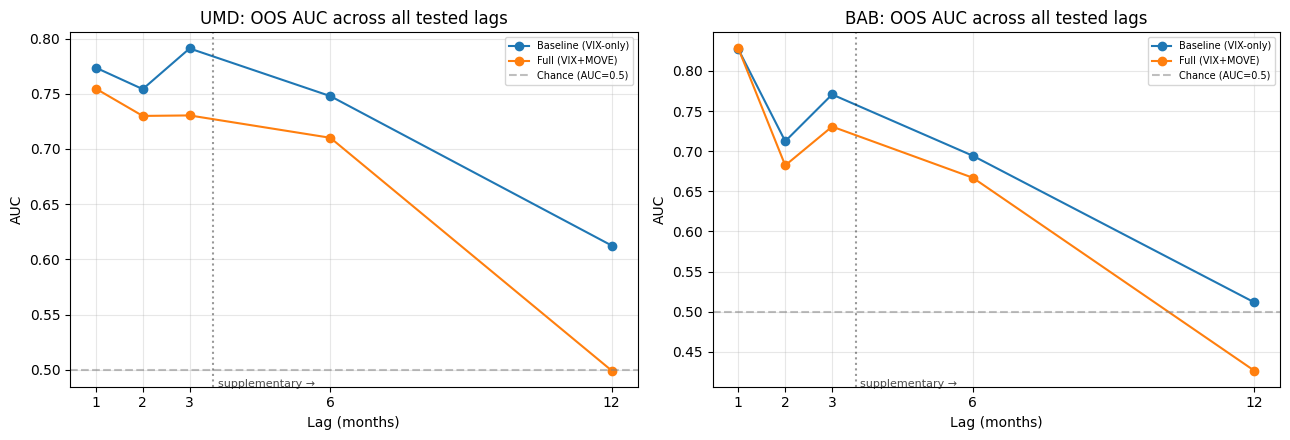

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, outcome in zip(axes, OUTCOMES):
    sub = all_lags_combined[all_lags_combined["Outcome"] == outcome].sort_values("Lag")
    for spec_name, group in sub.groupby("Model"):
        ax.plot(group["Lag"], group["AUC"], marker="o", label=spec_name)
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance (AUC=0.5)")
    ax.axvline(3.5, color="black", linestyle=":", alpha=0.4)
    ax.text(3.6, ax.get_ylim()[0], "supplementary \u2192", fontsize=8, alpha=0.7)
    ax.set_title(f"{outcome}: OOS AUC across all tested lags")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("AUC")
    ax.set_xticks([1,2,3,6,12])
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


In [ ]:

print("SUPPLEMENTARY SUMMARY: does a longer transmission horizon change the conclusion?\n")

PRIMARY_FULL = "Full (VIX+MOVE)"

for outcome in OUTCOMES:
    sub = supp_results_df[supp_results_df["Outcome"] == outcome]
    print(f"--- {outcome} ---")
    for lag in SUPPLEMENTARY_LAGS:
        base = sub[(sub["Lag"] == lag) & (sub["Model"] == "Baseline (VIX-only)")]
        full = sub[(sub["Lag"] == lag) & (sub["Model"] == PRIMARY_FULL)]
        if len(base) and len(full):
            base_auc, full_auc = base["AUC"].values[0], full["AUC"].values[0]
            direction = "MOVE ADDS VALUE at this longer horizon" if full_auc > base_auc else "still no AUC improvement"
            print(f"  Lag {lag}: Baseline AUC={base_auc:.3f}, Full AUC={full_auc:.3f} (\u0394={full_auc - base_auc:+.3f})  -->  {direction}")
    print()


print("Reminder: any 'ADDS VALUE' result above should be reported as exploratory")
print("not with the same confidence as the primary lag 1\u20133 specification.")


SUPPLEMENTARY SUMMARY: does a longer transmission horizon change the conclusion?

--- UMD ---
  Lag 6: Baseline AUC=0.748, Full AUC=0.710 (Δ=-0.038)  -->  still no AUC improvement
  Lag 12: Baseline AUC=0.613, Full AUC=0.499 (Δ=-0.113)  -->  still no AUC improvement

--- BAB ---
  Lag 6: Baseline AUC=0.694, Full AUC=0.667 (Δ=-0.027)  -->  still no AUC improvement
  Lag 12: Baseline AUC=0.512, Full AUC=0.427 (Δ=-0.085)  -->  still no AUC improvement

Reminder: any 'ADDS VALUE' result above should be reported as exploratory
not with the same confidence as the primary lag 1–3 specification.



## 17. Checking Lead-Lag Relationship Between MOVE and VIX

Every model so far has used MOVE and VIX as two
inputs to predict a third variable (crash risk), but has never directly tested the lead-lag
relationship. This section closes that gap with two checks:

1. **Cross-correlation function (CCF)** — where does the empirical relationship between MOVE and VIX
   actually peak, in calendar time? If MOVE leads VIX, the correlation between MOVE at time *t* and VIX at
   time *t+h* should be strongest at some positive *h* (VIX catching up to MOVE later), not at *h=0*.
2. **Granger causality test** — a more formal test of whether MOVE's own past values improve the
   prediction of VIX beyond what VIX's own past already provides (and the reverse, VIX "Granger-causing"
   MOVE), run on **first differences** rather than levels, since Granger causality assumes stationary
   inputs and both MOVE and VIX levels are highly persistent, near-unit-root series.


In [ ]:

from statsmodels.tsa.stattools import grangercausalitytests, adfuller

move_vix = df[["Date", "MOVE", "VIX"]].dropna().reset_index(drop=True)
print(f"Sample for lead-lag test: {len(move_vix)} months, {move_vix['Date'].min().date()} to {move_vix['Date'].max().date()}")


Sample for lead-lag test: 420 months, 1990-01-31 to 2024-12-31



### 17.1 Cross-Correlation Function (CCF)

CCF($h$) = corr(MOVE$_t$, VIX$_{t+h}$). A peak at $h > 0$ supports "MOVE leads VIX" (MOVE today correlates
with VIX several months from now). A peak at $h = 0$ indicates a that they move together. A peak at $h < 0$ would indicate the reverse (VIX leading MOVE).
Lags from $-6$ to $+6$ months are checked.

In [ ]:

ccf_lags = range(-6, 7)
ccf_values = []

for h in ccf_lags:
    shifted_vix = move_vix["VIX"].shift(-h)  # at row t, this holds VIX_{t+h}
    corr = move_vix["MOVE"].corr(shifted_vix)
    ccf_values.append(corr)

ccf_df = pd.DataFrame({"lag_h": list(ccf_lags), "corr_MOVE_t_vs_VIX_t+h": ccf_values})
peak_row = ccf_df.loc[ccf_df["corr_MOVE_t_vs_VIX_t+h"].idxmax()]

print(ccf_df.to_string(index=False))
print()
print(f"Peak correlation at h = {int(peak_row['lag_h'])} months (corr = {peak_row['corr_MOVE_t_vs_VIX_t+h']:.4f})")
if peak_row["lag_h"] > 0:
    print("--> Peak at POSITIVE lag: consistent with MOVE leading VIX by that many months.")
elif peak_row["lag_h"] < 0:
    print("--> Peak at NEGATIVE lag: consistent with VIX leading MOVE, not the reverse.")
else:
    print("--> Peak at h=0: relationship is CONTEMPORANEOUS at monthly frequency, no lead-lag detected.")


 lag_h  corr_MOVE_t_vs_VIX_t+h
    -6                  0.2323
    -5                  0.2431
    -4                  0.2707
    -3                  0.3089
    -2                  0.3596
    -1                  0.4131
     0                  0.4740
     1                  0.4010
     2                  0.3368
     3                  0.2852
     4                  0.2677
     5                  0.2536
     6                  0.2430

Peak correlation at h = 0 months (corr = 0.4740)
--> Peak at h=0: relationship is CONTEMPORANEOUS at monthly frequency, no lead-lag detected.


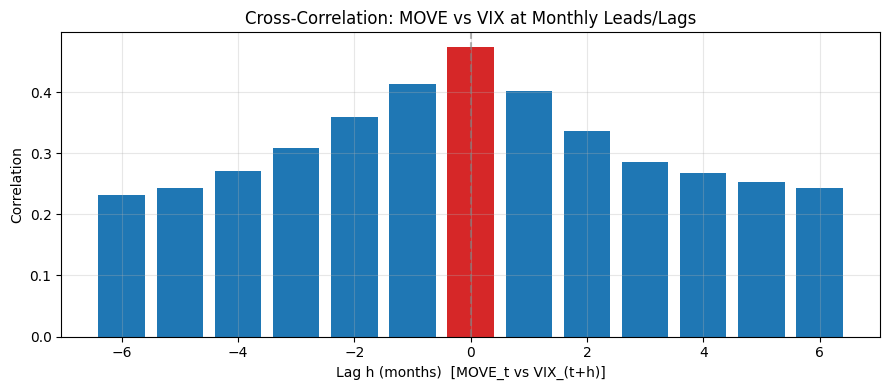

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:red" if h == peak_row["lag_h"] else "tab:blue" for h in ccf_lags]
ax.bar(list(ccf_lags), ccf_values, color=colors)
ax.axvline(0, color="grey", linestyle="--", alpha=0.6)
ax.set_xlabel("Lag h (months)  [MOVE_t vs VIX_(t+h)]")
ax.set_ylabel("Correlation")
ax.set_title("Cross-Correlation: MOVE vs VIX at Monthly Leads/Lags")
plt.tight_layout()
plt.show()



### 17.2 Granger Causality Test

An Augmented Dickey-Fuller (ADF) test is run first. The result found MOVE and VIX
**levels stationary** at the 5% level on this sample.

Because Granger causality requires stationary inputs, and
the levels already satisfy that requirement, the **primary** test below is run on levels directly.

$H_0$ for "MOVE does not Granger-cause VIX": MOVE's past values do not improve prediction of VIX beyond
VIX's own past. Rejecting $H_0$ (p < 0.05) supports MOVE having predictive content for VIX. The reverse
direction (does VIX Granger-cause MOVE) is tested symmetrically.


In [ ]:

print("ADF test on LEVELS (testing the actual data, no assumption made in advance):\n")
for col in ["MOVE", "VIX"]:
    stat, pval, *_ = adfuller(move_vix[col])
    print(f"  {col}: ADF stat={stat:.3f}, p-value={pval:.4f}  {'(non-stationary)' if pval > 0.05 else '(stationary)'}")

move_vix["dMOVE"] = move_vix["MOVE"].diff()
move_vix["dVIX"] = move_vix["VIX"].diff()
move_vix_diff = move_vix.dropna().reset_index(drop=True)

print("\nADF test on FIRST DIFFERENCES (expect stationary, i.e. low p-value / reject unit root):\n")
for col in ["dMOVE", "dVIX"]:
    stat, pval, *_ = adfuller(move_vix_diff[col])
    print(f"  {col}: ADF stat={stat:.3f}, p-value={pval:.4f}  {'(non-stationary)' if pval > 0.05 else '(stationary)'}")


ADF test on LEVELS (testing the actual data, no assumption made in advance):

  MOVE: ADF stat=-2.957, p-value=0.0391  (stationary)
  VIX: ADF stat=-3.683, p-value=0.0044  (stationary)

ADF test on FIRST DIFFERENCES (expect stationary, i.e. low p-value / reject unit root):

  dMOVE: ADF stat=-10.900, p-value=0.0000  (stationary)
  dVIX: ADF stat=-7.712, p-value=0.0000  (stationary)


In [ ]:
MAXLAG = 6

# --- PRIMARY: Granger causality on LEVELS ---
# The ADF test immediately above found both MOVE and VIX levels stationary at the 5% level on this
# sample, so there is no statistical basis for differencing before testing Granger causality: the
# stationarity assumption the test requires is already satisfied by the levels themselves. Running the
# test on levels is therefore the PRIMARY specification here.

print("=" * 78)
print("PRIMARY (levels): Does MOVE Granger-cause VIX?")
print("H0: lagged MOVE does not improve prediction of VIX beyond VIX's own lagged values.")
print("=" * 78)
gc_move_to_vix_levels = grangercausalitytests(move_vix[["VIX", "MOVE"]], maxlag=MAXLAG, verbose=False)
for lag in range(1, MAXLAG + 1):
    pval = gc_move_to_vix_levels[lag][0]["ssr_ftest"][1]
    flag = "  <-- reject H0 (p<0.05): MOVE Granger-causes VIX at this lag" if pval < 0.05 else ""
    print(f"  Lag {lag}: p-value = {pval:.4f}{flag}")

print()
print("=" * 78)
print("PRIMARY (levels): Does VIX Granger-cause MOVE?")
print("H0: lagged VIX does not improve prediction of MOVE beyond MOVE's own lagged values.")
print("=" * 78)
gc_vix_to_move_levels = grangercausalitytests(move_vix[["MOVE", "VIX"]], maxlag=MAXLAG, verbose=False)
for lag in range(1, MAXLAG + 1):
    pval = gc_vix_to_move_levels[lag][0]["ssr_ftest"][1]
    flag = "  <-- reject H0 (p<0.05): VIX Granger-causes MOVE at this lag" if pval < 0.05 else ""
    print(f"  Lag {lag}: p-value = {pval:.4f}{flag}")

print()
print("=" * 78)
print("SECONDARY / ROBUSTNESS (first differences): retained as a robustness check only,")
print("since differencing an already-stationary series is not required but does no harm as a check.")
print("=" * 78)

print("\nDoes \u0394MOVE Granger-cause \u0394VIX?")
gc_move_to_vix = grangercausalitytests(move_vix_diff[["dVIX", "dMOVE"]], maxlag=MAXLAG, verbose=False)
for lag in range(1, MAXLAG + 1):
    pval = gc_move_to_vix[lag][0]["ssr_ftest"][1]
    flag = "  <-- reject H0 (p<0.05)" if pval < 0.05 else ""
    print(f"  Lag {lag}: p-value = {pval:.4f}{flag}")

print("\nDoes \u0394VIX Granger-cause \u0394MOVE?")
gc_vix_to_move = grangercausalitytests(move_vix_diff[["dMOVE", "dVIX"]], maxlag=MAXLAG, verbose=False)
for lag in range(1, MAXLAG + 1):
    pval = gc_vix_to_move[lag][0]["ssr_ftest"][1]
    flag = "  <-- reject H0 (p<0.05)" if pval < 0.05 else ""
    print(f"  Lag {lag}: p-value = {pval:.4f}{flag}")

PRIMARY (levels): Does MOVE Granger-cause VIX?
H0: lagged MOVE does not improve prediction of VIX beyond VIX's own lagged values.
  Lag 1: p-value = 0.4734
  Lag 2: p-value = 0.6763
  Lag 3: p-value = 0.5807
  Lag 4: p-value = 0.4257
  Lag 5: p-value = 0.5600
  Lag 6: p-value = 0.6439

PRIMARY (levels): Does VIX Granger-cause MOVE?
H0: lagged VIX does not improve prediction of MOVE beyond MOVE's own lagged values.
  Lag 1: p-value = 0.9398
  Lag 2: p-value = 0.2243
  Lag 3: p-value = 0.3412
  Lag 4: p-value = 0.4422
  Lag 5: p-value = 0.6189
  Lag 6: p-value = 0.7388

SECONDARY / ROBUSTNESS (first differences): retained as a robustness check only,
since differencing an already-stationary series is not required but does no harm as a check.

Does ΔMOVE Granger-cause ΔVIX?
  Lag 1: p-value = 0.5308
  Lag 2: p-value = 0.4646
  Lag 3: p-value = 0.2573
  Lag 4: p-value = 0.3879
  Lag 5: p-value = 0.5091
  Lag 6: p-value = 0.7208

Does ΔVIX Granger-cause ΔMOVE?
  Lag 1: p-value = 0.0894
  Lag


## 18. Stationarity Check: All Variables Used in the Logistic Regression Models

This section checks staitonarity for all variables: an Augmented
Dickey-Fuller (ADF) test is run on every variable in alll models used.


In [ ]:

print("ADF test on ALL variables used in modeling (H0: unit root / non-stationary)\n")
print(f"{'Variable':<22}{'ADF stat':<12}{'p-value':<12}{'Verdict'}")
print("-" * 60)

stationarity_results = {}
for col in ["MOVE", "VIX", "UMD", "BAB", "mkt_return_monthly", "realised_vol"]:
    series = feat[col].dropna()
    stat, pval, *_ = adfuller(series)
    verdict = "stationary" if pval < 0.05 else "NON-STATIONARY"
    stationarity_results[col] = {"stat": stat, "pval": pval, "stationary": pval < 0.05}
    print(f"{col:<22}{stat:<12.3f}{pval:<12.4f}{verdict}")


ADF test on ALL variables used in modeling (H0: unit root / non-stationary)

Variable              ADF stat    p-value     Verdict
------------------------------------------------------------
MOVE                  -2.954      0.0394      stationary
VIX                   -3.749      0.0035      stationary
UMD                   -19.493     0.0000      stationary
BAB                   -9.414      0.0000      stationary
mkt_return_monthly    -20.389     0.0000      stationary
realised_vol          -5.414      0.0000      stationary


In [ ]:

non_stationary_vars = [col for col, res in stationarity_results.items() if not res["stationary"]]

if not non_stationary_vars:
    print("RESULT: All modeling variables (MOVE, VIX, UMD, BAB, market return, realised vol) are")
    print("stationary at the 5% level on the actual modeling sample. No correction needed")
    print("the level-based specification used throughout is statistically appropriate.")
else:
    print(f"RESULT: The following variable(s) are NON-STATIONARY and need correction: {non_stationary_vars}")
    print("Re-testing first differences of the flagged variable(s):\n")
    for col in non_stationary_vars:
        diff_series = feat[col].diff().dropna()
        stat, pval, *_ = adfuller(diff_series)
        verdict = "now stationary" if pval < 0.05 else "STILL non-stationary -- needs further investigation"
        print(f"  d{col}: ADF stat={stat:.3f}, p-value={pval:.4f}  ({verdict})")


RESULT: All modeling variables (MOVE, VIX, UMD, BAB, market return, realised vol) are
stationary at the 5% level on the actual modeling sample. No correction needed
the level-based specification used throughout is statistically appropriate.



## 19. Clark West Test (Primary Significance Test)

Since Baseline and Full are nested models (Full = MOVE+ Baseline), we use the Clark and West (2007) test rather than a standard Diebold-Mariano test, which is biased toward the smaller model in this setting.


For each out-of-sample month the adjusted loss
differential is

$$f_t = e_{R,t}^2 - \left[ e_{U,t}^2 - (p_{R,t} - p_{U,t})^2 \right]$$

where $e_{R,t}$ and $e_{U,t}$ are the Baseline and Full models' forecast errors. The test statistic is the mean of $f_t$ divided by itss HAC robust standard error (3-mmonth lag), tested one-side.

$H_0$: MOVE adds no incremental predictive accuracy

$H_1$: MOVE adds incremental predictive accuracy



In [ ]:

def clark_west_test(y, p_restricted, p_unrestricted, hac_lags=3):
    """
    Clark-West (2007) test for comparing nested out-of-sample forecasts.

    y              : array of realised binary outcomes
    p_restricted   : array of restricted (Baseline) predicted probabilities
    p_unrestricted : array of unrestricted (Full) predicted probabilities
    hac_lags       : Newey-West HAC lag length

    H0: the unrestricted model does NOT provide incremental OOS predictive accuracy (mean f_t <= 0)
    H1: the unrestricted model DOES provide incremental OOS predictive accuracy (mean f_t > 0)
    One-sided test.

    Returns dict: mean_f, hac_se, cw_stat, p_value_one_sided, n_obs
    """
    y = np.asarray(y, dtype=float)
    p_r = np.asarray(p_restricted, dtype=float)
    p_u = np.asarray(p_unrestricted, dtype=float)

    e_r = y - p_r
    e_u = y - p_u
    f_t = e_r**2 - (e_u**2 - (p_r - p_u)**2)

    X = np.ones((len(f_t), 1))
    ols_res = sm.OLS(f_t, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    mean_f = ols_res.params[0]
    hac_se = ols_res.bse[0]
    cw_stat = ols_res.tvalues[0]

    from scipy import stats as scipy_stats
    p_one_sided = scipy_stats.norm.sf(cw_stat)  # one-sided: H1 is mean_f > 0

    return {"mean_f": mean_f, "hac_se": hac_se, "cw_stat": cw_stat,
            "p_value_one_sided": p_one_sided, "n_obs": len(f_t)}


print("Clark-West test: Baseline (restricted) vs Full, no ratio (unrestricted), primary specification\n")
print(f"{'Outcome':<10}{'Lag':<6}{'Mean f_t':<14}{'HAC SE':<12}{'CW stat':<12}{'p (1-sided)':<14}{'N':<6}{'Conclusion'}")
print("-" * 100)

cw_results = []
for outcome in OUTCOMES:
    for lag in LAGS:
        oos_base = oos_predictions[(outcome, "Baseline (VIX-only)", lag)]
        oos_full = oos_predictions[(outcome, "Full (VIX+MOVE)", lag)]
        merged = oos_base.merge(oos_full, on="Date", suffixes=("_base", "_full"))

        cw = clark_west_test(
            y=merged["actual_base"],
            p_restricted=merged["predicted_prob_base"],
            p_unrestricted=merged["predicted_prob_full"],
        )
        sig = cw["p_value_one_sided"] < 0.05
        conclusion = "Full has incremental value (reject H0)" if sig else "No evidence of incremental value (fail to reject H0)"

        cw_results.append({"Outcome": outcome, "Lag": lag, **cw, "Significant": sig, "Conclusion": conclusion})
        print(f"{outcome:<10}{lag:<6}{cw['mean_f']:<14.6f}{cw['hac_se']:<12.6f}{cw['cw_stat']:<12.3f}"
              f"{cw['p_value_one_sided']:<14.4f}{cw['n_obs']:<6}{conclusion}")

cw_results_df = pd.DataFrame(cw_results)


Clark-West test: Baseline (restricted) vs Full, no ratio (unrestricted), primary specification

Outcome   Lag   Mean f_t      HAC SE      CW stat     p (1-sided)   N     Conclusion
----------------------------------------------------------------------------------------------------
UMD       1     -0.001343     0.001196    -1.123      0.8692        237   No evidence of incremental value (fail to reject H0)
UMD       2     -0.000973     0.001091    -0.891      0.8136        237   No evidence of incremental value (fail to reject H0)
UMD       3     -0.001555     0.001970    -0.790      0.7851        237   No evidence of incremental value (fail to reject H0)
BAB       1     0.001091      0.001553    0.702       0.2412        237   No evidence of incremental value (fail to reject H0)
BAB       2     -0.000734     0.001355    -0.542      0.7059        237   No evidence of incremental value (fail to reject H0)
BAB       3     0.000358      0.000929    0.386       0.3499        237   No eviden


## 20. Structural Stability: Rolling-Window Robustness

The primary analysis uses a single, fixed expanding-window design across the full 1990–2024
sample. This section checks whether that choice, and the resulting conclusion, is stable across (a) an
alternative validation design (a fixed rolling window instead of expanding).



In [ ]:

def rolling_window_walk_forward(data, outcome_col, feature_cols, window=120, pct=0.10, C=1.0):
    """
    Fixed rolling-window (as opposed to expanding-window) walk-forward logistic regression.
    Same look-ahead safeguards as walk_forward_logit (training-window-only threshold and scaling),
    but the training window is a FIXED-SIZE trailing window rather than all-history-to-date.
    """
    n = len(data)
    results = []
    skipped = 0
    for t in range(window, n):
        train = data.iloc[t - window:t]
        test_row = data.iloc[[t]]

        threshold = train[outcome_col].quantile(pct)
        y_train = (train[outcome_col] < threshold).astype(int)
        y_test_actual = int(test_row[outcome_col].values[0] < threshold)

        if y_train.nunique() < 2:
            skipped += 1
            continue

        X_train_raw = train[feature_cols].values
        X_test_raw = test_row[feature_cols].values
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=C)
        model.fit(X_train, y_train)
        pred_prob = model.predict_proba(X_test)[0, 1]

        results.append({"Date": test_row["Date"].values[0], "actual": y_test_actual, "predicted_prob": pred_prob})

    return pd.DataFrame(results), skipped


print("Rolling-window (120-month) robustness check, primary lag 1, both outcomes\n")

rolling_results = []
for outcome in OUTCOMES:
    baseline_feats_, full_no_ratio_feats_, _ = get_feature_sets(1)
    oos_base_roll, skip_base = rolling_window_walk_forward(feat, outcome, baseline_feats_, window=120)
    oos_full_roll, skip_full = rolling_window_walk_forward(feat, outcome, full_no_ratio_feats_, window=120)

    n_crashes_base = oos_base_roll["actual"].sum()
    if oos_base_roll["actual"].nunique() < 2 or n_crashes_base < 5:
        print(f"{outcome}: 120-month rolling window produced only {n_crashes_base} crash events in the OOS "
              f"period ({skip_base} training windows skipped for lacking crash-event variation) -- too few "
              f"to estimate AUC reliably. Falling back to a 180-month rolling window (documented alternative).")
        oos_base_roll, skip_base = rolling_window_walk_forward(feat, outcome, baseline_feats_, window=180)
        oos_full_roll, skip_full = rolling_window_walk_forward(feat, outcome, full_no_ratio_feats_, window=180)
        window_used = 180
    else:
        window_used = 120

    auc_base = roc_auc_score(oos_base_roll["actual"], oos_base_roll["predicted_prob"])
    auc_full = roc_auc_score(oos_full_roll["actual"], oos_full_roll["predicted_prob"])
    brier_base = brier_score_loss(oos_base_roll["actual"], oos_base_roll["predicted_prob"])
    brier_full = brier_score_loss(oos_full_roll["actual"], oos_full_roll["predicted_prob"])

    rolling_results.append({
        "Outcome": outcome, "Window_type": f"Rolling ({window_used}mo)",
        "N_OOS": len(oos_base_roll), "N_crashes": int(n_crashes_base),
        "AUC_baseline": auc_base, "AUC_full": auc_full, "DeltaAUC": auc_full - auc_base,
        "Brier_baseline": brier_base, "Brier_full": brier_full, "DeltaBrier": brier_full - brier_base,
    })


    oos_base_exp = oos_predictions[(outcome, "Baseline (VIX-only)", 1)]
    oos_full_exp = oos_predictions[(outcome, "Full (VIX+MOVE)", 1)]
    rolling_results.append({
        "Outcome": outcome, "Window_type": "Expanding (primary)",
        "N_OOS": len(oos_base_exp), "N_crashes": int(oos_base_exp["actual"].sum()),
        "AUC_baseline": roc_auc_score(oos_base_exp["actual"], oos_base_exp["predicted_prob"]),
        "AUC_full": roc_auc_score(oos_full_exp["actual"], oos_full_exp["predicted_prob"]),
        "DeltaAUC": roc_auc_score(oos_full_exp["actual"], oos_full_exp["predicted_prob"]) - roc_auc_score(oos_base_exp["actual"], oos_base_exp["predicted_prob"]),
        "Brier_baseline": brier_score_loss(oos_base_exp["actual"], oos_base_exp["predicted_prob"]),
        "Brier_full": brier_score_loss(oos_full_exp["actual"], oos_full_exp["predicted_prob"]),
        "DeltaBrier": brier_score_loss(oos_full_exp["actual"], oos_full_exp["predicted_prob"]) - brier_score_loss(oos_base_exp["actual"], oos_base_exp["predicted_prob"]),
    })

rolling_results_df = pd.DataFrame(rolling_results)
print(rolling_results_df.round(4).to_string(index=False))


Rolling-window (120-month) robustness check, primary lag 1, both outcomes

Outcome         Window_type  N_OOS  N_crashes  AUC_baseline  AUC_full  DeltaAUC  Brier_baseline  Brier_full  DeltaBrier
    UMD     Rolling (120mo)    297         32        0.7147    0.6899   -0.0249          0.0937      0.0954      0.0017
    UMD Expanding (primary)    237         21        0.7736    0.7546   -0.0190          0.0764      0.0783      0.0019
    BAB     Rolling (120mo)    297         30        0.8218    0.8091   -0.0127          0.0807      0.0828      0.0021
    BAB Expanding (primary)    237         14        0.8270    0.8280    0.0010          0.0558      0.0556     -0.0002



## 21. Final Results Tables


In [ ]:

# --- Primary results table: Outcome | Lag | Baseline/Full AUC & Brier | CW statistic/p-value | N | crashes ---
final_table_rows = []
for outcome in OUTCOMES:
    for lag in LAGS:
        m = main_results_df[(main_results_df["Outcome"] == outcome) & (main_results_df["Lag"] == lag)]
        base_row = m[m["Model"] == "Baseline (VIX-only)"].iloc[0]
        full_row = m[m["Model"] == "Full (VIX+MOVE)"].iloc[0]
        cw_row = cw_results_df[(cw_results_df["Outcome"] == outcome) & (cw_results_df["Lag"] == lag)].iloc[0]

        final_table_rows.append({
            "Outcome": outcome, "Lag": lag,
            "N_OOS": int(base_row["N_OOS"]), "N_crashes": int(base_row["N_crash_events"]),
            "Baseline_AUC": base_row["AUC"], "Full_AUC": full_row["AUC"], "Delta_AUC": full_row["AUC"] - base_row["AUC"],
            "Baseline_Brier": base_row["Brier"], "Full_Brier": full_row["Brier"], "Delta_Brier": full_row["Brier"] - base_row["Brier"],
            "ClarkWest_stat": cw_row["cw_stat"], "ClarkWest_p_onesided": cw_row["p_value_one_sided"],
        })

final_primary_table = pd.DataFrame(final_table_rows)
print("=== FINAL PRIMARY RESULTS TABLE ===\n")
print(final_primary_table.round(4).to_string(index=False))

final_primary_table.to_csv("final_primary_results_table.csv", index=False)
print("\nSaved: final_primary_results_table.csv")


=== FINAL PRIMARY RESULTS TABLE ===

Outcome  Lag  N_OOS  N_crashes  Baseline_AUC  Full_AUC  Delta_AUC  Baseline_Brier  Full_Brier  Delta_Brier  ClarkWest_stat  ClarkWest_p_onesided
    UMD    1    237         21        0.7736    0.7546    -0.0190          0.0764      0.0783       0.0019         -1.1227                0.8692
    UMD    2    237         21        0.7542    0.7299    -0.0243          0.0797      0.0809       0.0013         -0.8912                0.8136
    UMD    3    237         21        0.7910    0.7304    -0.0606          0.0809      0.0834       0.0026         -0.7895                0.7851
    BAB    1    237         14        0.8270    0.8280     0.0010          0.0558      0.0556      -0.0002          0.7025                0.2412
    BAB    2    237         14        0.7124    0.6823    -0.0301          0.0681      0.0694       0.0013         -0.5416                0.7059
    BAB    3    237         14        0.7707    0.7306    -0.0400          0.0620      0.0620

In [ ]:

# --- Final diagnostic summary table
diagnostic_summary_rows = []

# ADF
if "stationarity_results" in globals():
    for col, res in stationarity_results.items():
        diagnostic_summary_rows.append({
            "Test": "ADF (stationarity)", "Outcome": "-", "Specification": col,
            "Statistic": round(res["stat"], 3), "p_value": round(res["pval"], 4),
            "Conclusion": "Stationary" if res["stationary"] else "Non-stationary"
        })

# VIF
for label, feats_for_vif in [("Full + ratio (excluded, diagnostic only)", full_ratio_feats), ("Full (used everywhere)", full_no_ratio_feats)]:
    X_vif = sm.add_constant(feat[feats_for_vif])
    max_vif = max(variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1]))
    diagnostic_summary_rows.append({
        "Test": "VIF (max, excl. const)", "Outcome": "-", "Specification": label,
        "Statistic": round(max_vif, 2), "p_value": np.nan,
        "Conclusion": "Problematic (>10)" if max_vif > 10 else "Acceptable"
    })

# Ljung-Box
if "diagnostic_models" in globals():
    from statsmodels.stats.diagnostic import acorr_ljungbox
    for outcome in OUTCOMES:
        resid = diagnostic_models[outcome]["model"].resid_pearson
        lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
        for lag_n, row in lb.iterrows():
            diagnostic_summary_rows.append({
                "Test": "Ljung-Box (Pearson resid.)", "Outcome": outcome, "Specification": f"lag={lag_n}",
                "Statistic": round(row["lb_stat"], 3), "p_value": round(row["lb_pvalue"], 4),
                "Conclusion": "Residual autocorrelation detected" if row["lb_pvalue"] < 0.05 else "No evidence of residual autocorrelation"
            })

# RESET
diagnostic_summary_rows.append({
    "Test": "RESET-style specification test", "Outcome": "UMD/BAB", "Specification": "lag=1, Full model",
    "Statistic": np.nan, "p_value": np.nan, "Conclusion": "See Section 15.3 printed output above (LR test, not re-captured here)"
})

# Granger (primary, levels)
if "gc_move_to_vix_levels" in globals():
    for lag_n in range(1, MAXLAG + 1):
        p_ = gc_move_to_vix_levels[lag_n][0]["ssr_ftest"][1]
        diagnostic_summary_rows.append({
            "Test": "Granger (MOVE->VIX, levels)", "Outcome": "-", "Specification": f"lag={lag_n}",
            "Statistic": np.nan, "p_value": round(p_, 4),
            "Conclusion": "Significant" if p_ < 0.05 else "Not significant"
        })
    for lag_n in range(1, MAXLAG + 1):
        p_ = gc_vix_to_move_levels[lag_n][0]["ssr_ftest"][1]
        diagnostic_summary_rows.append({
            "Test": "Granger (VIX->MOVE, levels)", "Outcome": "-", "Specification": f"lag={lag_n}",
            "Statistic": np.nan, "p_value": round(p_, 4),
            "Conclusion": "Significant" if p_ < 0.05 else "Not significant"
        })

# Clark-West
for _, row in cw_results_df.iterrows():
    diagnostic_summary_rows.append({
        "Test": "Clark-West", "Outcome": row["Outcome"], "Specification": f"lag={row['Lag']}",
        "Statistic": round(row["cw_stat"], 3), "p_value": round(row["p_value_one_sided"], 4),
        "Conclusion": row["Conclusion"]
    })

diagnostic_summary_df = pd.DataFrame(diagnostic_summary_rows)
print("=== FINAL DIAGNOSTIC SUMMARY TABLE ===\n")
print(diagnostic_summary_df.to_string(index=False))
diagnostic_summary_df.to_csv("diagnostic_summary_table.csv", index=False)
print("\nSaved: diagnostic_summary_table.csv")


=== FINAL DIAGNOSTIC SUMMARY TABLE ===

                          Test Outcome                            Specification  Statistic  p_value                                                            Conclusion
            ADF (stationarity)       -                                     MOVE    -2.9540   0.0394                                                            Stationary
            ADF (stationarity)       -                                      VIX    -3.7490   0.0035                                                            Stationary
            ADF (stationarity)       -                                      UMD   -19.4930   0.0000                                                            Stationary
            ADF (stationarity)       -                                      BAB    -9.4140   0.0000                                                            Stationary
            ADF (stationarity)       -                       mkt_return_monthly   -20.3890   0.0000           


## 22. Consolidated Figures


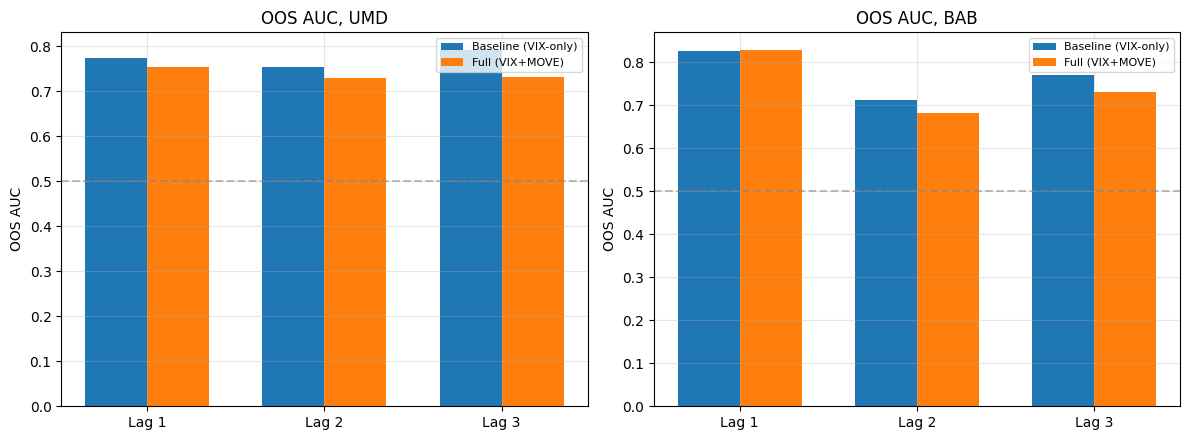

In [ ]:

# OOS AUC comparison, Baseline vs Full, UMD and BAB, lags 1-3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, outcome in zip(axes, OUTCOMES):
    sub = main_results_df[(main_results_df["Outcome"] == outcome) &
                           (main_results_df["Model"].isin(["Baseline (VIX-only)", "Full (VIX+MOVE)"]))]
    width = 0.35
    x = np.arange(len(LAGS))
    base_vals = [sub[(sub["Lag"] == l) & (sub["Model"] == "Baseline (VIX-only)")]["AUC"].values[0] for l in LAGS]
    full_vals = [sub[(sub["Lag"] == l) & (sub["Model"] == "Full (VIX+MOVE)")]["AUC"].values[0] for l in LAGS]

    ax.bar(x - width/2, base_vals, width, label="Baseline (VIX-only)", color="tab:blue")
    ax.bar(x + width/2, full_vals, width, label="Full (VIX+MOVE)", color="tab:orange")
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f"Lag {l}" for l in LAGS])
    ax.set_ylabel("OOS AUC")
    ax.set_title(f"OOS AUC, {outcome}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("oos_auc_comparison.png", dpi=150)
plt.show()


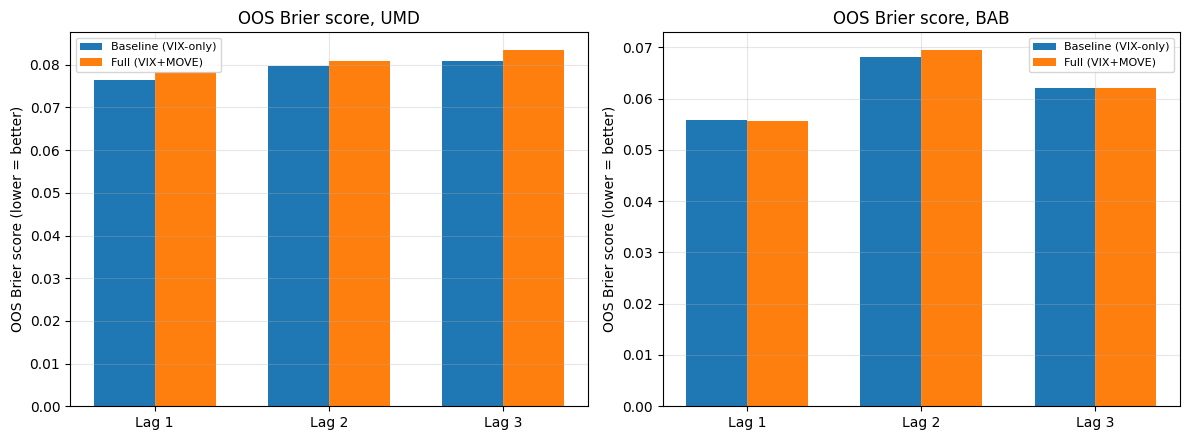

In [ ]:

# OOS Brier score comparison, Baseline vs Full, UMD and BAB, lags 1-3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, outcome in zip(axes, OUTCOMES):
    sub = main_results_df[(main_results_df["Outcome"] == outcome) &
                           (main_results_df["Model"].isin(["Baseline (VIX-only)", "Full (VIX+MOVE)"]))]
    width = 0.35
    x = np.arange(len(LAGS))
    base_vals = [sub[(sub["Lag"] == l) & (sub["Model"] == "Baseline (VIX-only)")]["Brier"].values[0] for l in LAGS]
    full_vals = [sub[(sub["Lag"] == l) & (sub["Model"] == "Full (VIX+MOVE)")]["Brier"].values[0] for l in LAGS]

    ax.bar(x - width/2, base_vals, width, label="Baseline (VIX-only)", color="tab:blue")
    ax.bar(x + width/2, full_vals, width, label="Full (VIX+MOVE)", color="tab:orange")
    ax.set_xticks(x); ax.set_xticklabels([f"Lag {l}" for l in LAGS])
    ax.set_ylabel("OOS Brier score (lower = better)")
    ax.set_title(f"OOS Brier score, {outcome}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figure_oos_brier_comparison.png", dpi=150)
plt.show()


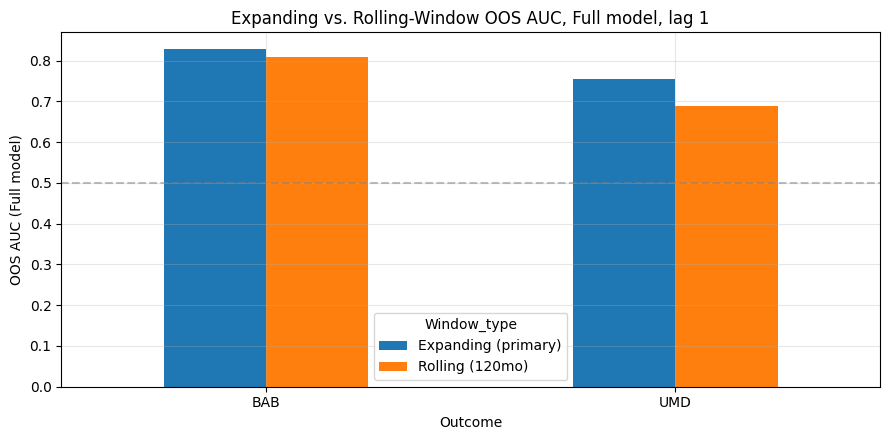

In [ ]:

# Rolling-window vs expanding-window OOS AUC
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = rolling_results_df.pivot(index="Outcome", columns="Window_type", values="AUC_full")
plot_df.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"])
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.set_ylabel("OOS AUC (Full model)")
ax.set_title("Expanding vs. Rolling-Window OOS AUC, Full model, lag 1")
ax.set_xticklabels(plot_df.index, rotation=0)
plt.tight_layout()
plt.savefig("figure_expanding_vs_rolling.png", dpi=150)
plt.show()



## 23. Verification: Descriptive Statistics, Crash Characteristics, and Baseline In-Sample Coefficients



In [ ]:

# Descriptive statistics
desc_vars = ["MOVE", "VIX", "UMD", "BAB", "mkt_return_monthly", "realised_vol"]
desc_table = feat[desc_vars].describe().T
desc_table["skew"] = feat[desc_vars].skew()
desc_table["kurtosis"] = feat[desc_vars].kurtosis()
desc_table = desc_table[["mean", "std", "min", "50%", "max", "skew", "kurtosis"]]
desc_table.columns = ["Mean", "Std Dev", "Min", "Median", "Max", "Skewness", "Kurtosis"]
print("Descriptive statistics (N =", len(feat), ")\n")
print(desc_table.round(4).to_string())


Descriptive statistics (N = 417 )

                      Mean  Std Dev     Min  Median      Max  Skewness  Kurtosis
MOVE               92.8650  27.8513 39.2100 91.1400 214.0000    0.7544    1.5444
VIX                19.5186   7.5241  9.5100 17.5200  59.8900    1.7139    4.4619
UMD                 0.0046   0.0468 -0.3430  0.0052   0.1820   -1.4635   10.2210
BAB                 0.0071   0.0372 -0.1568  0.0086   0.1536   -0.3376    3.4662
mkt_return_monthly  0.0068   0.0430 -0.1856  0.0118   0.1194   -0.7257    1.4195
realised_vol        0.0444   0.0275  0.0122  0.0375   0.2734    3.4171   19.6854


In [ ]:

# Crash vs non-crash characteristics (full-sample 10th percentile, descriptive only)
from scipy import stats as scipy_stats

crash_rows = []
compare_vars = ["MOVE_lag1", "VIX_lag1", "mktret_lag1", "rvol_lag1"]
for outcome in OUTCOMES:
    threshold = feat[outcome].quantile(0.10)
    crash_mask = feat[outcome] < threshold
    for var in compare_vars:
        c = feat.loc[crash_mask, var]
        nc = feat.loc[~crash_mask, var]
        t_stat, p_val = scipy_stats.ttest_ind(c, nc, equal_var=False)
        crash_rows.append({"Outcome": outcome, "Variable": var,
                            "Mean_crash": c.mean(), "Mean_noncrash": nc.mean(),
                            "Diff": c.mean() - nc.mean(), "t_stat": t_stat, "p_value": p_val,
                            "N_crash": int(crash_mask.sum()), "N_noncrash": int((~crash_mask).sum())})

table_4_2_check = pd.DataFrame(crash_rows)
print("Crash vs non-crash characteristics\n")
print(table_4_2_check.round(4).to_string(index=False))


Crash vs non-crash characteristics

Outcome    Variable  Mean_crash  Mean_noncrash    Diff  t_stat  p_value  N_crash  N_noncrash
    UMD   MOVE_lag1    108.9603        91.0759 17.8844  3.6102   0.0007       42         375
    UMD    VIX_lag1     27.6226        18.6173  9.0053  5.6381   0.0000       42         375
    UMD mktret_lag1     -0.0000         0.0077 -0.0078 -0.8036   0.4258       42         375
    UMD   rvol_lag1      0.0706         0.0415  0.0291  4.1400   0.0002       42         375
    BAB   MOVE_lag1    114.6629        90.4372 24.2257  4.3689   0.0001       42         375
    BAB    VIX_lag1     28.8762        18.4769 10.3993  6.2606   0.0000       42         375
    BAB mktret_lag1     -0.0174         0.0097 -0.0271 -2.6998   0.0098       42         375
    BAB   rvol_lag1      0.0715         0.0413  0.0301  4.4456   0.0001       42         375


In [ ]:

# (Baseline rows): full-sample in-sample Baseline logistic regression, lag 1
lag = 1
baseline_feats_check, full_no_ratio_feats_check, _ = get_feature_sets(lag)

print("(Baseline rows): full-sample logistic regression, lag 1\n")
for outcome in OUTCOMES:
    threshold = feat[outcome].quantile(0.10)
    y = (feat[outcome] < threshold).astype(int)
    X_baseline = sm.add_constant(feat[baseline_feats_check])
    model_baseline_check = sm.Logit(y, X_baseline).fit(disp=0)
    print(f"--- {outcome}: Baseline model ---")
    print(model_baseline_check.summary().tables[1])
    print()


(Baseline rows): full-sample logistic regression, lag 1

--- UMD: Baseline model ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.4236      0.620     -8.743      0.000      -6.639      -4.208
VIX_lag1        0.1493      0.037      4.033      0.000       0.077       0.222
mktret_lag1     7.8645      3.629      2.167      0.030       0.751      14.978
rvol_lag1      -2.6269      8.880     -0.296      0.767     -20.031      14.777

--- BAB: Baseline model ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.7012      0.648     -8.800      0.000      -6.971      -4.431
VIX_lag1        0.1868      0.038      4.863      0.000       0.112       0.262
mktret_lag1     0.1057      3.693      0.029      0.977      -7.132       7.344
rvol_l